<a href="https://colab.research.google.com/github/RafihaikalP/Rafi-Haikal-Pratama_2411532002_ML_2526/blob/main/Praktikum4/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [6]:
dataset_url = 'https://raw.githubusercontent.com/RafihaikalP/Rafi-Haikal-Pratama_2411532002_ML_2526/refs/heads/main/Praktikum4/Advertising.csv'

df = pd.read_csv(dataset_url)

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
dataset_url = 'https://raw.githubusercontent.com/RafihaikalP/Rafi-Haikal-Pratama_2411532002_ML_2526/refs/heads/main/Praktikum4/Advertising.csv'

df = pd.read_csv(dataset_url)

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [8]:
df.info()
df.describe()

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Data fitur:")
print(X.head())

print("\nData target:")
print(y.head())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
Data fitur:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Data target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64
Jumlah data training: 160
Jumlah data testing: 40


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

X_train_scaled_df.head()

,TV,Radio,Newspaper
0,-0.404248,-1.028237,-0.337675
1,0.320608,-0.919828,-1.161439
2,-1.270511,0.259124,0.254251
3,-1.042359,-0.696233,-0.574446
4,0.879103,-1.387343,-0.707629


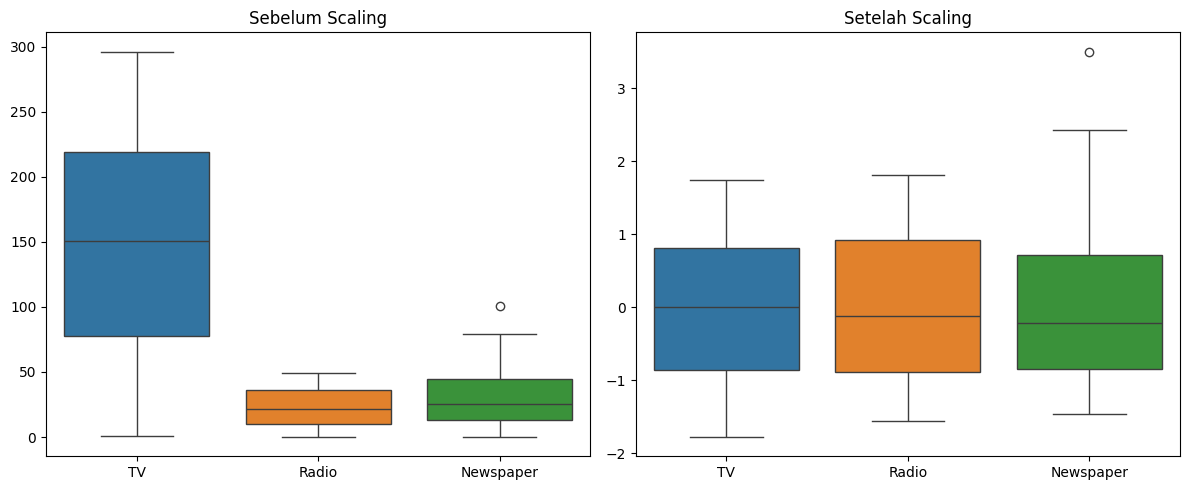

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=X_train, ax=ax[0])
ax[0].set_title("Sebelum Scaling")

sns.boxplot(data=X_train_scaled_df, ax=ax[1])
ax[1].set_title("Setelah Scaling")

plt.tight_layout()
plt.show()

In [11]:
def hitung_rmse(model, X_train_data, X_test_data, y_train, y_test):
    y_pred_train = model.predict(X_train_data)
    y_pred_test = model.predict(X_test_data)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    gap_rmse = abs(rmse_test - rmse_train)

    return rmse_train, rmse_test, gap_rmse

In [12]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

rmse_train_linear, rmse_test_linear, gap_linear = hitung_rmse(
    linear_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

coef_linear = pd.Series(linear_model.coef_, index=X.columns)

print("Linear Regression")
print("RMSE Train:", rmse_train_linear)
print("RMSE Test :", rmse_test_linear)
print("Gap RMSE  :", gap_linear)
print("\nKoefisien Linear Regression:")
print(coef_linear)

Linear Regression
RMSE Train: 1.644727765644337
RMSE Test : 1.7815996615334506
Gap RMSE  : 0.13687189588911353

Koefisien Linear Regression:
TV           3.764196
Radio        2.792307
Newspaper    0.055976
dtype: float64


In [13]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

rmse_train_ridge, rmse_test_ridge, gap_ridge = hitung_rmse(
    ridge_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

coef_ridge = pd.Series(ridge_model.coef_, index=X.columns)

print("Ridge Regression alpha=1.0")
print("RMSE Train:", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Gap RMSE  :", gap_ridge)
print("\nKoefisien Ridge:")
print(coef_ridge)

Ridge Regression alpha=1.0
RMSE Train: 1.6449869251443512
RMSE Test : 1.7872201577332218
Gap RMSE  : 0.14223323258887066

Koefisien Ridge:
TV           3.741693
Radio        2.773312
Newspaper    0.063380
dtype: float64


In [14]:
lasso_model = Lasso(alpha=0.1, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

rmse_train_lasso, rmse_test_lasso, gap_lasso = hitung_rmse(
    lasso_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

coef_lasso = pd.Series(lasso_model.coef_, index=X.columns)

print("Lasso Regression alpha=0.1")
print("RMSE Train:", rmse_train_lasso)
print("RMSE Test :", rmse_test_lasso)
print("Gap RMSE  :", gap_lasso)
print("\nKoefisien Lasso:")
print(coef_lasso)

Lasso Regression alpha=0.1
RMSE Train: 1.651292955720115
RMSE Test : 1.7913338117315942
Gap RMSE  : 0.1400408560114792

Koefisien Lasso:
TV           3.669206
Radio        2.719147
Newspaper    0.000000
dtype: float64


In [15]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

hasil_alpha = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)

    rmse_train, rmse_test, gap = hitung_rmse(
        ridge,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    hasil_alpha.append({
        "Model": "Ridge",
        "Alpha": alpha,
        "RMSE Train": rmse_train,
        "RMSE Test": rmse_test,
        "Gap RMSE": gap
    })

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)

    rmse_train, rmse_test, gap = hitung_rmse(
        lasso,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    hasil_alpha.append({
        "Model": "Lasso",
        "Alpha": alpha,
        "RMSE Train": rmse_train,
        "RMSE Test": rmse_test,
        "Gap RMSE": gap
    })

hasil_alpha_df = pd.DataFrame(hasil_alpha)
hasil_alpha_df

,Model,Alpha,RMSE Train,RMSE Test,Gap RMSE
0,Ridge,0.001,1.644728,1.781605,0.136877
1,Lasso,0.001,1.644728,1.781587,0.136859
2,Ridge,0.010,1.644728,1.781654,0.136926
3,Lasso,0.010,1.644799,1.781551,0.136752
4,Ridge,0.100,1.644730,1.782143,0.137412
5,Lasso,0.100,1.651293,1.791334,0.140041
6,Ridge,1.000,1.644987,1.787220,0.142233
7,Lasso,1.000,2.146055,2.396806,0.250751
8,Ridge,10.000,1.667636,1.853716,0.186080
9,Lasso,10.000,5.092764,5.631496,0.538732


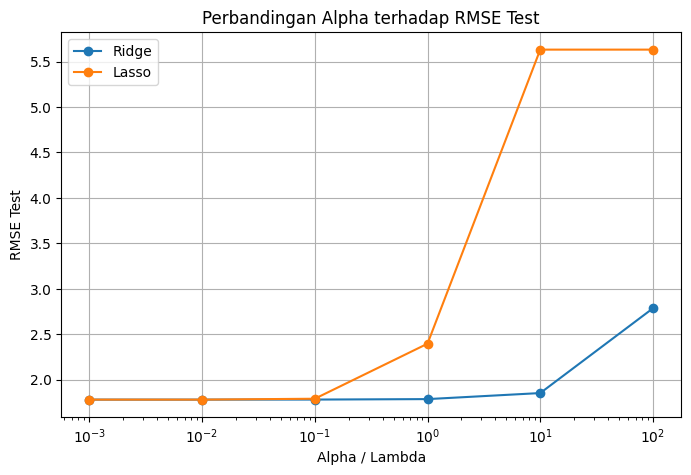

In [16]:
plt.figure(figsize=(8, 5))

for model in ["Ridge", "Lasso"]:
    data_model = hasil_alpha_df[hasil_alpha_df["Model"] == model]

    plt.plot(
        data_model["Alpha"],
        data_model["RMSE Test"],
        marker="o",
        label=model
    )

plt.xscale("log")
plt.xlabel("Alpha / Lambda")
plt.ylabel("RMSE Test")
plt.title("Perbandingan Alpha terhadap RMSE Test")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
hasil_terbaik = hasil_alpha_df.loc[hasil_alpha_df["RMSE Test"].idxmin()]

print("Model terbaik berdasarkan RMSE Test:")
print(hasil_terbaik)

Model terbaik berdasarkan RMSE Test:
Model            Lasso
Alpha             0.01
RMSE Train    1.644799
RMSE Test     1.781551
Gap RMSE      0.136752
Name: 3, dtype: object
